<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/Convolutional_NN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Problem Statement` :
The task at hand involves classifying images of cats and dogs using a
Convolutional Neural Network (CNN). We have a dataset containing images of
cats and dogs and the objective is to train a CNN model to accurately predict the class of each image.

`Objectives` :

`Data Preparation` :

● Download and extract the cats vs. dogs dataset.

● Organize the dataset into a structured directory format suitable for
TensorFlow’s ImageDataGenerator.

● Split the dataset into training and testing sets.

`Data Augmentation and Preprocessing` :

● Implement data augmentation techniques to increase the diversity of the
training dataset, aiding in the model's ability to generalize.

● Normalize the pixel values of the images for optimal model performance.

`Model Building` :

● Construct a Convolutional Neural Network using TensorFlow and Keras.

● Themodel should contain multiple convolutional layers, pooling layers, and
fully connected layers.

`Training` :

● Compile the model and train it on the prepared dataset.

● Utilize categorical cross entropy as the loss function and stochastic
gradient descent as the optimizer.

● Train the model for a sufficient number of epochs to achieve good
performance.

`Evaluation` :

● Evaluate the model's performance on the validation set during training to
monitor for overfitting.

● After training, assess the model's accuracy and make predictions on the
test set.

`Prediction` :

● Implement a system to make predictions on new images, categorizing
them as either cat or dog.

● Thesystem should be able to take an image (or a batch of images),
preprocess it, and pass it through the model for prediction.

### `Step 1` : Import Libraries

In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

### `Step 2` : Loading Image Manually



In [16]:
# Load images
cat_img = image.load_img('cat.jpg', target_size=(150,150))
dog_img = image.load_img('dog.jpg', target_size=(150,150))

# Convert to array
cat_array = image.img_to_array(cat_img) / 255.0
dog_array = image.img_to_array(dog_img) / 255.0

### `Step 3` : Create Dataset

In [17]:
# Features
X = np.array([cat_array, dog_array])

# Labels (0 = Cat, 1 = Dog)
y = np.array([0, 1])

print("Shape of X:", X.shape)
print("Labels:", y)

Shape of X: (2, 150, 150, 3)
Labels: [0 1]


### `Step 4` : Visualize Images

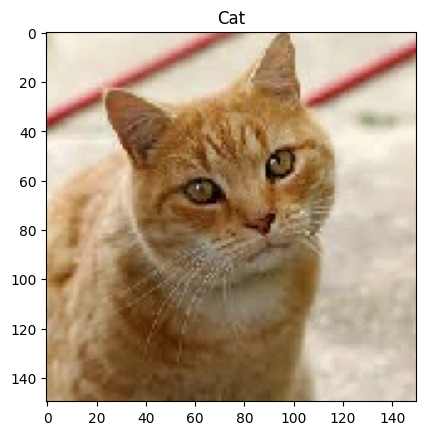

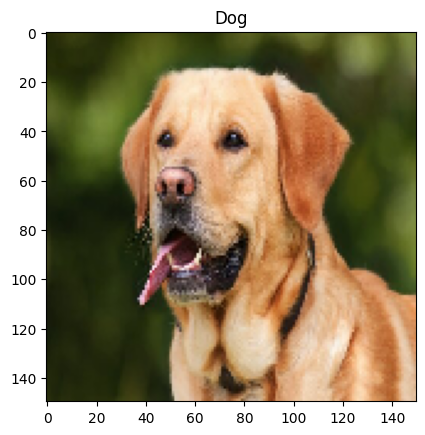

In [18]:
plt.imshow(cat_array)
plt.title("Cat")
plt.show()

plt.imshow(dog_array)
plt.title("Dog")
plt.show()

### `Step 5` : Build CNN Model

In [19]:
model = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

### `Step 6` : Compile Model

In [20]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### `Step 7` : Train Model

In [21]:
history = model.fit(
    X, y,
    epochs=10,
    batch_size=1
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5000 - loss: 1.3079 
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.7192
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5000 - loss: 0.6546
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.6265 
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.5945
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.5538
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.5369
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.4683
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.4582
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.3925


### `Step 8` : Check Training Result

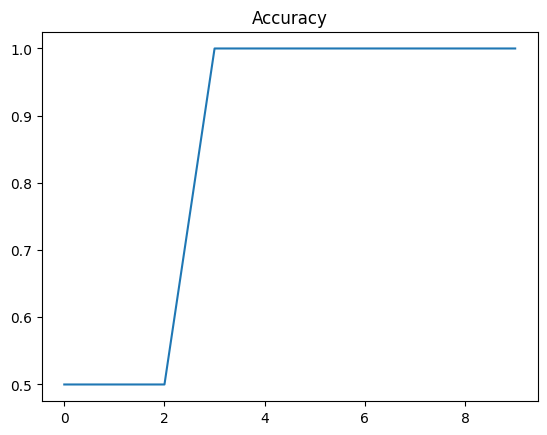

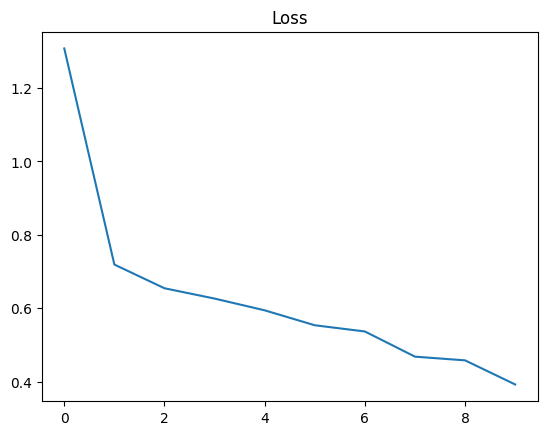

In [22]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.title("Loss")
plt.show()

### `Step 9` : Test Prediction

In [23]:
# Test on cat image
test_img = image.load_img('cat.jpg', target_size=(150,150))
test_array = image.img_to_array(test_img) / 255.0
test_array = np.expand_dims(test_array, axis=0)

prediction = model.predict(test_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Cat
